# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-05-11 20:12:15.447477: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-11 20:12:15.521252: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 20:12:15.850523: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-11 20:12:15.850626: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-11 20:12:15.851431: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    X_train = np.loadtxt(f"{root_dir}/train/X_train.txt")
    # 2. Load y_train from train/y_train.txt
    y_train = np.loadtxt(f"{root_dir}/train/y_train.txt", dtype = int)
    # 3. Load X_test from test/X_test.txt
    X_test = np.loadtxt(f"{root_dir}/test/X_test.txt")
    # 4. Load y_test from test/y_test.txt
    y_test = np.loadtxt(f"{root_dir}/test/y_test.txt", dtype = int)
    # 5. Convert the labels to zero-based class indices by subtracting 1

    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#

num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

table = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "num samples": (np.sum(y_train == i) for i in range(num_classes))
})
print(table)


   Class Index          Class Name  num samples
0            0             WALKING         1226
1            1    WALKING_UPSTAIRS         1073
2            2  WALKING_DOWNSTAIRS          986
3            3             SITTING         1286
4            4            STANDING         1374
5            5              LAYING         1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    # Define Sequential model with 3 layers
    model = keras.Sequential(
        [
            keras.Input(shape=(input_dim)),
            layers.Dense(256, activation="relu", name="h1"),
            layers.Dense(128, activation="relu", name="h2"),
            layers.Dense(64, activation="relu", name="h3"),
            layers.Dense(num_classes, activation="softmax", name="output")
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 h1 (Dense)                  (None, 256)               143872    
                                                                 
 h2 (Dense)                  (None, 128)               32896     
                                                                 


2026-05-11 20:12:26.109688: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 20:12:26.111134: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 h3 (Dense)                  (None, 64)                8256      
                                                                 
 output (Dense)              (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

history = baseline_model.fit(
    x=X_train,
    y=y_train,
    batch_size=64,
    epochs=40,
    callbacks=callbacks,
    validation_split=0.2,
)


Epoch 1/40
92/92 [==============================] - 3s 12ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 8ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 1s 10ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 9ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 9ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [

### Training Curves


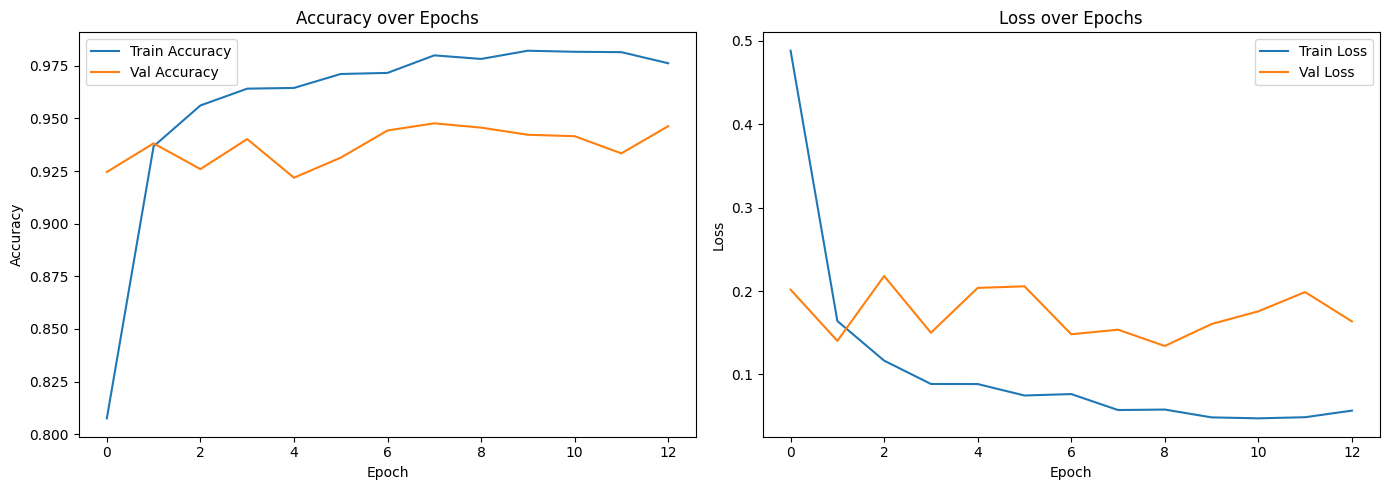

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 3ms/step
Test Accuracy: 0.9220
                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



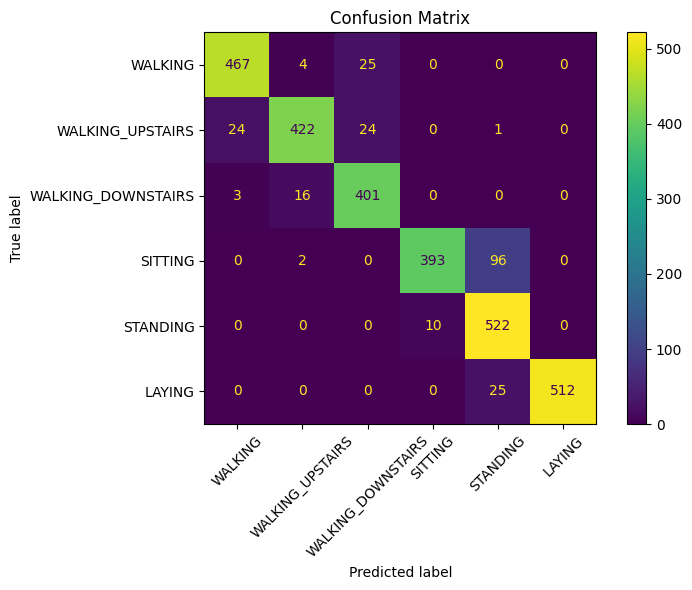

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
y_prob = baseline_model.predict(X_test)

# 2. Convert them to class predictions using argmax
y_pred = np.argmax(y_prob, axis=1)

# 3. Compute test accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 4. Print the classification report
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    
    # <-- Enter your code here <--#

    indexes = random.sample(range(X_train.shape[0]), 300)
    for i in indexes:
        sample = np.array([X_train[i]], dtype=np.float32)  
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] in (np.int8, np.uint8):
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        # <-- Enter your code here <--#
        
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        # <-- Enter your code here <--#

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    
    return converter.convert()
    


## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#

m_fp32 = convert_to_tflite_fp32(baseline_model)
m_dr = convert_to_tflite_dynamic_range(baseline_model)
m_f16 = convert_to_tflite_float16(baseline_model)
m_i8 = convert_to_tflite_int8(baseline_model)

models = {
    "fp32": m_fp32,
    "dynamic_range": m_dr,
    "float16": m_f16,
    "int8": m_i8
}
sizes = {}
for name, m in models.items():
    path = f"{name}.tflite"
    with open(path, "wb") as f:
        f.write(m)
    sizes[name] = os.path.getsize(path) / 1024 


##
accuracies = {}
for name, m in models.items():
    acc, _ = evaluate_tflite_model(m, X_test, y_test)
    accuracies[name] = acc

summary = pd.DataFrame({
    "Model":    list(models.keys()),
    "Size(KB)": [sizes[n]      for n in models.keys()],
    "Accuracy": [accuracies[n] for n in models.keys()]
})

print(summary)
    




INFO:tensorflow:Assets written to: /tmp/tmphp4evecd/assets


INFO:tensorflow:Assets written to: /tmp/tmphp4evecd/assets
2026-05-11 20:12:40.695647: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-11 20:12:40.695768: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-11 20:12:40.697538: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphp4evecd
2026-05-11 20:12:40.698804: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-11 20:12:40.698898: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmphp4evecd
2026-05-11 20:12:40.706172: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-11 20:12:40.707228: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-11 20:12:40.766270: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmp2bmfztco/assets


INFO:tensorflow:Assets written to: /tmp/tmp2bmfztco/assets
2026-05-11 20:12:42.919954: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-11 20:12:42.920034: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-11 20:12:42.920244: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp2bmfztco
2026-05-11 20:12:42.921373: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-11 20:12:42.921396: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp2bmfztco
2026-05-11 20:12:42.924032: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-11 20:12:42.965522: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp2bmfztco
2026-05-11 20:12:42.976740: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp7ix5mvtd/assets


INFO:tensorflow:Assets written to: /tmp/tmp7ix5mvtd/assets
2026-05-11 20:12:45.155537: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-11 20:12:45.155625: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-11 20:12:45.155809: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7ix5mvtd
2026-05-11 20:12:45.156561: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-11 20:12:45.156577: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7ix5mvtd
2026-05-11 20:12:45.160001: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-11 20:12:45.237119: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp7ix5mvtd
2026-05-11 20:12:45.255085: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpfa4meyqb/assets


INFO:tensorflow:Assets written to: /tmp/tmpfa4meyqb/assets
/home/brookewd/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-11 20:12:47.707721: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-11 20:12:47.707821: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-11 20:12:47.708008: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfa4meyqb
2026-05-11 20:12:47.709029: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-11 20:12:47.709051: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfa4meyqb
2026-05-11 20:12:47.716651: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


           Model    Size(KB)  Accuracy
0           fp32  726.660156  0.921955
1  dynamic_range  186.054688  0.921276
2        float16  365.628906  0.921955
3           int8  185.273438  0.921955


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

comparison_df = pd.DataFrame({
    "Model Family":   ["Baseline DNN"] * len(models),
    "Format":         list(models.keys()),
    "Test Accuracy":  [accuracies[k] for k in models],
    "Model Size (KB)":[sizes[k]      for k in models]
})

print(comparison_df)


   Model Family         Format  Test Accuracy  Model Size (KB)
0  Baseline DNN           fp32       0.921955       726.660156
1  Baseline DNN  dynamic_range       0.921276       186.054688
2  Baseline DNN        float16       0.921955       365.628906
3  Baseline DNN           int8       0.921955       185.273438


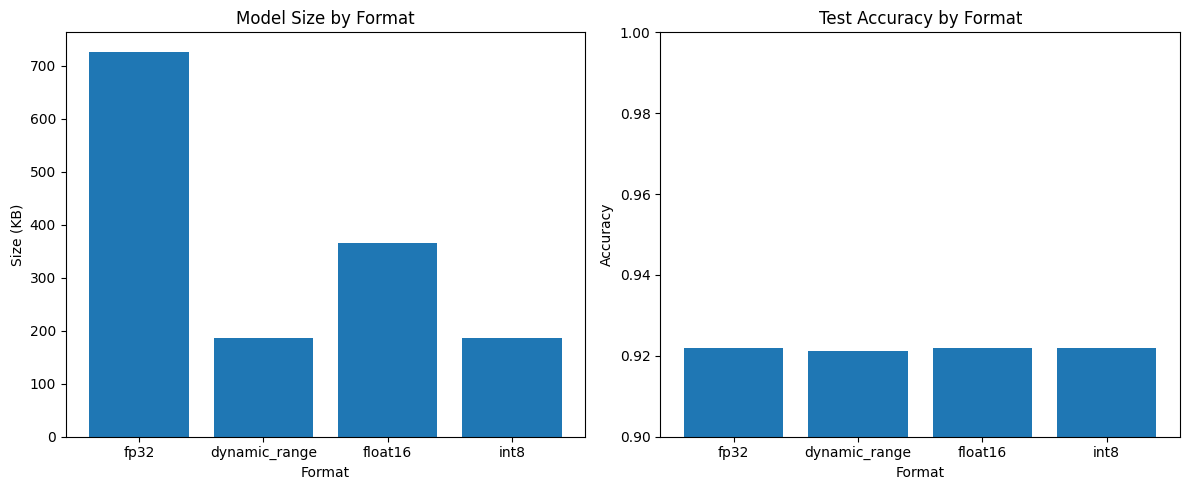

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Model Size
ax1.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
ax1.set_title("Model Size by Format")
ax1.set_xlabel("Format")
ax1.set_ylabel("Size (KB)")

# Test Accuracy
ax2.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
ax2.set_title("Test Accuracy by Format")
ax2.set_xlabel("Format")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.9, 1.0)  # zoom in since accuracy values are close together

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


                    precision    recall  f1-score   support

           WALKING       0.94      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



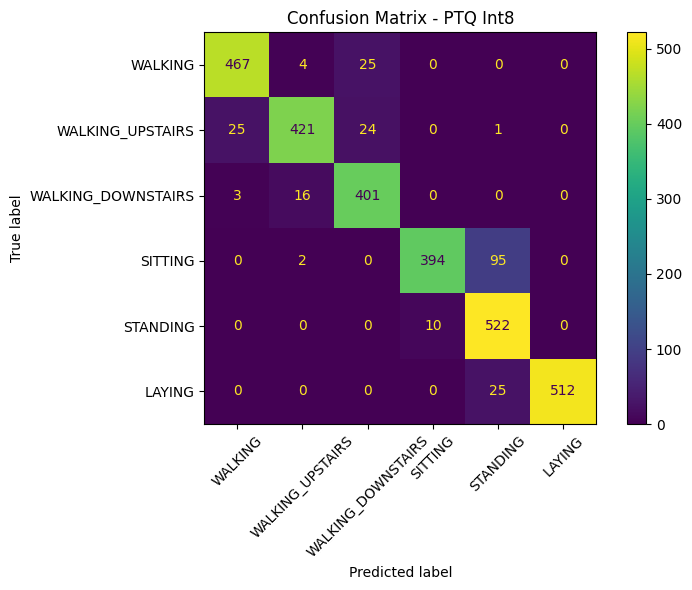

In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
# Get predictions from the int8 model
acc_i8, y_pred_i8 = evaluate_tflite_model(m_i8, X_test, y_test)

# Classification report
print(classification_report(y_test, y_pred_i8, target_names=class_names))

# Confusion matrix
cm_i8 = confusion_matrix(y_test, y_pred_i8)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_i8, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - PTQ Int8")
plt.tight_layout()
plt.show()


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

quant_aware_model = tfmot.quantization.keras.quantize_model(baseline_model)

quant_aware_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # ← lower lr than baseline (1e-3)
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

quant_aware_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_h1 (QuantizeWrapperV  (None, 256)               143877    
 2)                                                              
                                                                 
 quant_h2 (QuantizeWrapperV  (None, 128)               32901     
 2)                                                              
                                                                 
 quant_h3 (QuantizeWrapperV  (None, 64)                8261      
 2)                                                              
                                                                 
 quant_output (QuantizeWrap  (None, 6)                 3

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = quant_aware_model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2
)




Epoch 1/8
92/92 [==============================] - 3s 12ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 1s 8ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 1s 8ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [=========

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#

qat_loss, qat_accuracy = quant_aware_model.evaluate(X_test, y_test)
print(f"QAT Test Accuracy: {qat_accuracy:.4f}")

y_pred_qat_keras = np.argmax(quant_aware_model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred_qat_keras, target_names=class_names))


93/93 [==============================] - 0s 4ms/step - loss: 0.2461 - accuracy: 0.9321
QAT Test Accuracy: 0.9321
93/93 [==============================] - 1s 4ms/step
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.84      0.98      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(quant_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
qat_i8_model = converter.convert()
with open("qat_int8.tflite", "wb") as f:
    f.write(qat_i8_model)
qat_i8_size = os.path.getsize("qat_int8.tflite") / 1024
qat_i8_acc, y_pred_qat_i8 = evaluate_tflite_model(qat_i8_model, X_test, y_test)



INFO:tensorflow:Assets written to: /tmp/tmpio9_4708/assets


INFO:tensorflow:Assets written to: /tmp/tmpio9_4708/assets
/home/brookewd/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-11 20:13:05.401405: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-11 20:13:05.401485: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-11 20:13:05.401683: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpio9_4708
2026-05-11 20:13:05.403556: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-11 20:13:05.403587: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpio9_4708
2026-05-11 20:13:05.409062: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

comparison_qat_df = pd.DataFrame({
    "Model":          ["PTQ Int8", "QAT Int8"],
    "Test Accuracy":  [accuracies["int8"], qat_i8_acc],
    "Model Size (KB)":[sizes["int8"],      qat_i8_size]
})
print(comparison_qat_df)


      Model  Test Accuracy  Model Size (KB)
0  PTQ Int8       0.921955       185.273438
1  QAT Int8       0.931795       186.164062


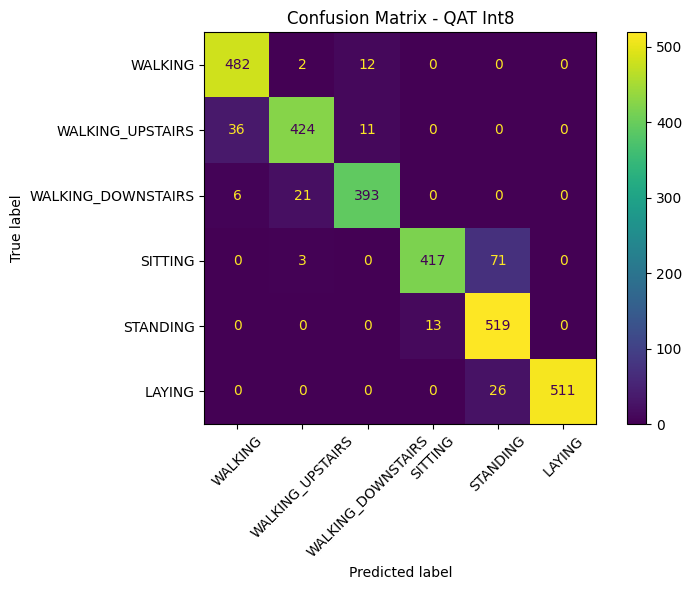

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#

cm_qat = confusion_matrix(y_test, y_pred_qat_i8)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_qat, display_labels=class_names).plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - QAT Int8")
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
